## Homework B1 <br>
Bristish Medical Submissions on a weekend <br>
* No-pooling: intercepts vary independently and do not share information
* Partial-pooling: intercepts share (or pool) information <br>
Prabhakar Srivastava

In [52]:
# Libraries
import pandas as pd
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pymc as pm
import arviz as az
from scipy.special import expit

Set Random seed and plotting style

In [4]:
# Random seed
seed_ = sum(map(ord, "Statistical Rethinking B1 Homework BMJ Submissions"))
random_seed = default_rng(seed_)

# Arviz docs
az.style.use("arviz-doc")

Download the data

In [10]:
file_path_str:str = "https://raw.githubusercontent.com/rmcelreath/stat_rethinking_2026/main/homework/BMJSubmissions.csv"

df = pd.read_csv(file_path_str, sep=",")
df.head()

,T,Y,country_name,L,W,H
0,11.766667,2012,Canada,7,0,0
1,10.516667,2012,Italy,18,0,0
2,13.516667,2012,Netherlands,21,0,0
3,19.483333,2012,United Kingdom,37,0,0
4,14.400000,2012,United Kingdom,37,0,0


Plot weekend submission rate by country

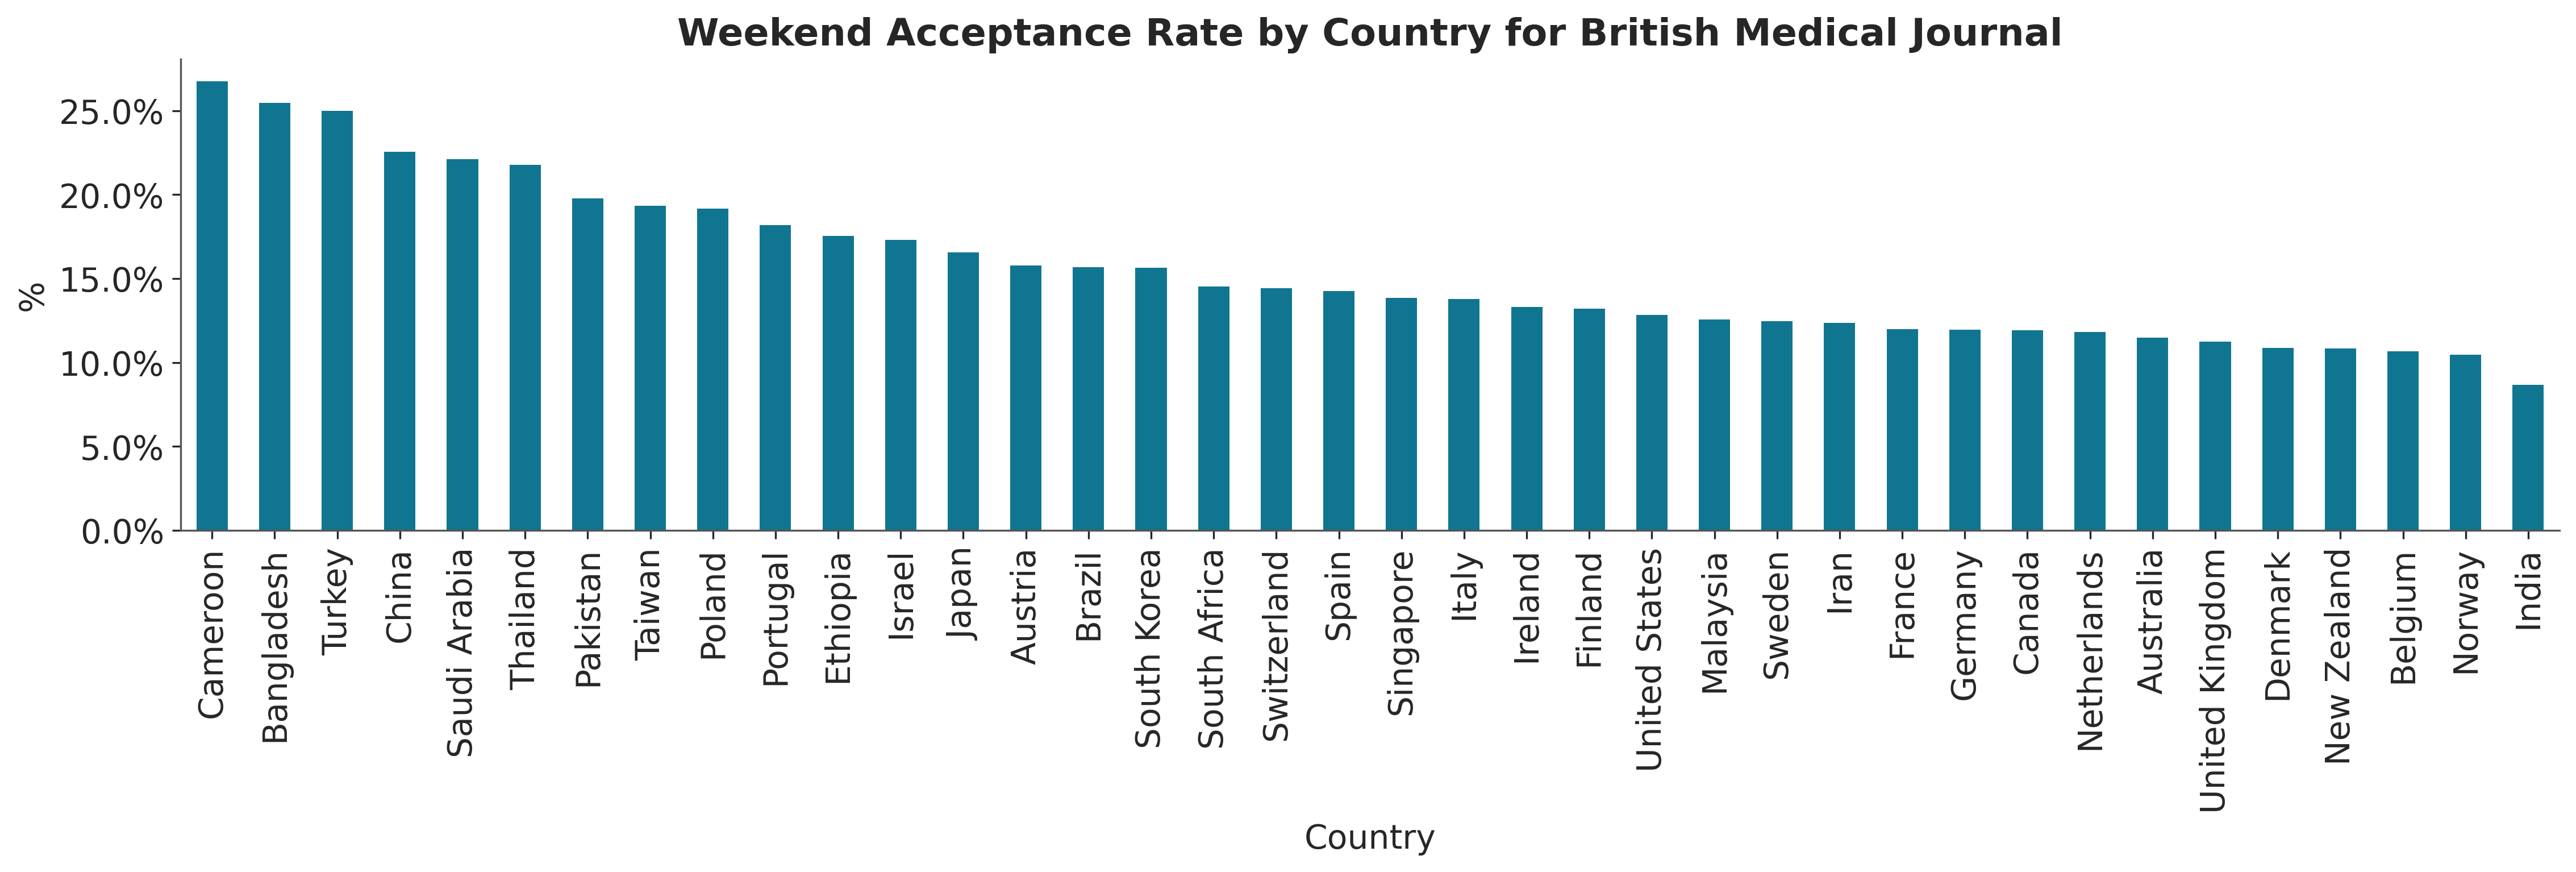

In [22]:
fig, ax = plt.subplots(figsize=(15, 5))

summary_df = (
    df
    .groupby("country_name")
    ["W"]
    .mean()
    .reset_index()
    .rename(columns = {"W": "weekend_rate"})
    .sort_values(by="weekend_rate", ascending=False)
)

summary_df.plot(x="country_name", y="weekend_rate", kind="bar", ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.get_legend().remove()
ax.set_title("Weekend Acceptance Rate by Country for British Medical Journal")
ax.set_ylabel("%")
ax.set_xlabel("Country")
plt.show()

No pooling Model <br>
* Each country varies independently of the other with no sharing of information in each <br>
The model looks as follows: 
<center> $\mu = a + b[id]$ </center>
<center> $p = invlogit(\mu)$ </center>
<center> $a \sim Normal(0, 1)$ </center>
<center> $b \sim Norma(0, 1)$ </center>

In [27]:
# Create dims
country_idx, countries = pd.factorize(df["country_name"], sort=True)

COORDS = {"country": countries,
         "obs": np.arange(0, len(df))
         }

In [43]:
with pm.Model(coords=COORDS) as no_pooled:

    # Data
    country_id = pm.Data("country_id", country_idx, dims="obs")
    W = pm.Data("W", df["W"].values, dims="obs")

    # Priors
    a = pm.Normal("a", mu=-1., sigma=1.) # Overall intercept
    b = pm.Normal("b", mu=0., sigma=0.5, dims="country") # No pooled model

    # Calculate probability
    p = pm.math.invlogit(a + b[country_id])
    # Likelihood
    W_obs = pm.Bernoulli("W_obs", p=p, observed=W, dims="obs")
    

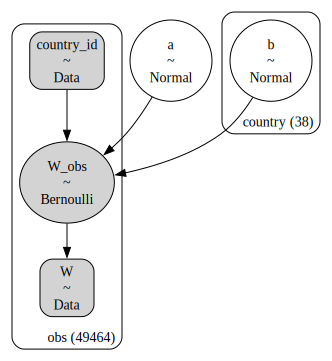

In [44]:
pm.model_to_graphviz(no_pooled)

In [45]:
# Sampling
with no_pooled:
    idata_no_pooled = pm.sample(random_seed=random_seed)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 48 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [46]:
az.summary(idata_no_pooled, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,-1.76,0.08,-1.93,-1.62,0.0,0.0,347.88,745.99,1.01
b[Australia],-0.28,0.10,-0.46,-0.09,0.0,0.0,486.24,1287.52,1.00
b[Austria],0.06,0.20,-0.31,0.43,0.0,0.0,1967.90,2691.34,1.00
b[Bangladesh],0.56,0.22,0.14,0.97,0.0,0.0,2343.68,2718.02,1.00
b[Belgium],-0.33,0.18,-0.66,0.01,0.0,0.0,1518.13,2315.63,1.00
b[Brazil],0.07,0.13,-0.19,0.31,0.0,0.0,859.80,1830.55,1.00
b[Cameroon],0.61,0.23,0.20,1.04,0.0,0.0,3073.22,2702.27,1.00
b[Canada],-0.24,0.10,-0.42,-0.06,0.0,0.0,488.00,1079.31,1.00
b[China],0.52,0.09,0.35,0.69,0.0,0.0,384.18,886.87,1.01
b[Denmark],-0.34,0.11,-0.55,-0.12,0.0,0.0,636.95,1255.19,1.00


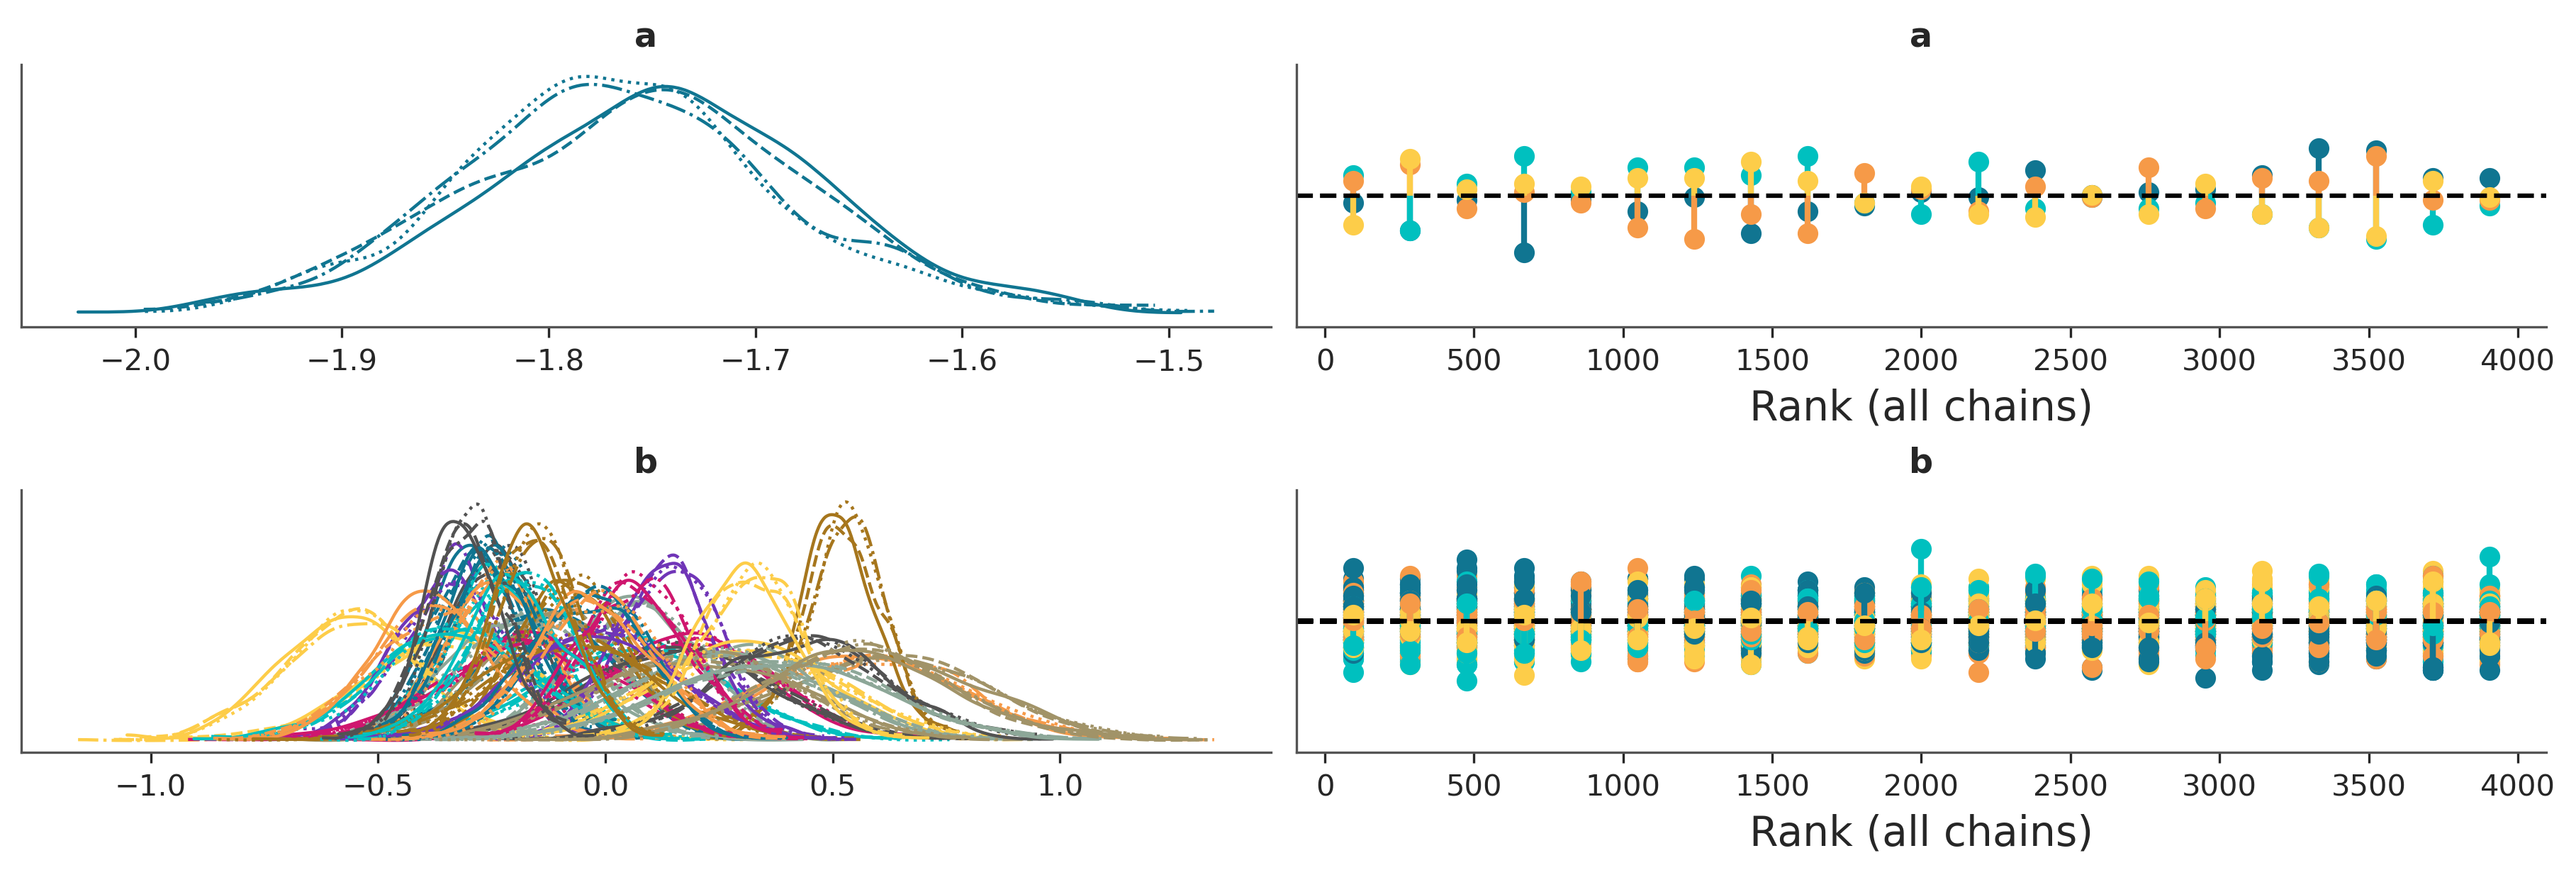

In [50]:
az.plot_trace(idata_no_pooled, kind="rank_vlines")
plt.show()

Let use visualize the probabilities of submitting on a weekend

In [74]:
prob_weekend_no_pool = expit(idata_no_pooled.posterior["a"] + idata_no_pooled.posterior["b"])
prob_weekend_no_pool = prob_weekend_no_pool.rename("prob_weekend")

In [87]:
# Reordering to make the plotting look better
countries_dict = {country:i for i, country in enumerate(countries)}
new_countries_dict = {country: countries_dict[country] for country in summary_df["country_name"]}

In [68]:
# Average of submission across all countries
global_avg = df["W"].mean().item()
global_avg

0.13894953905870935

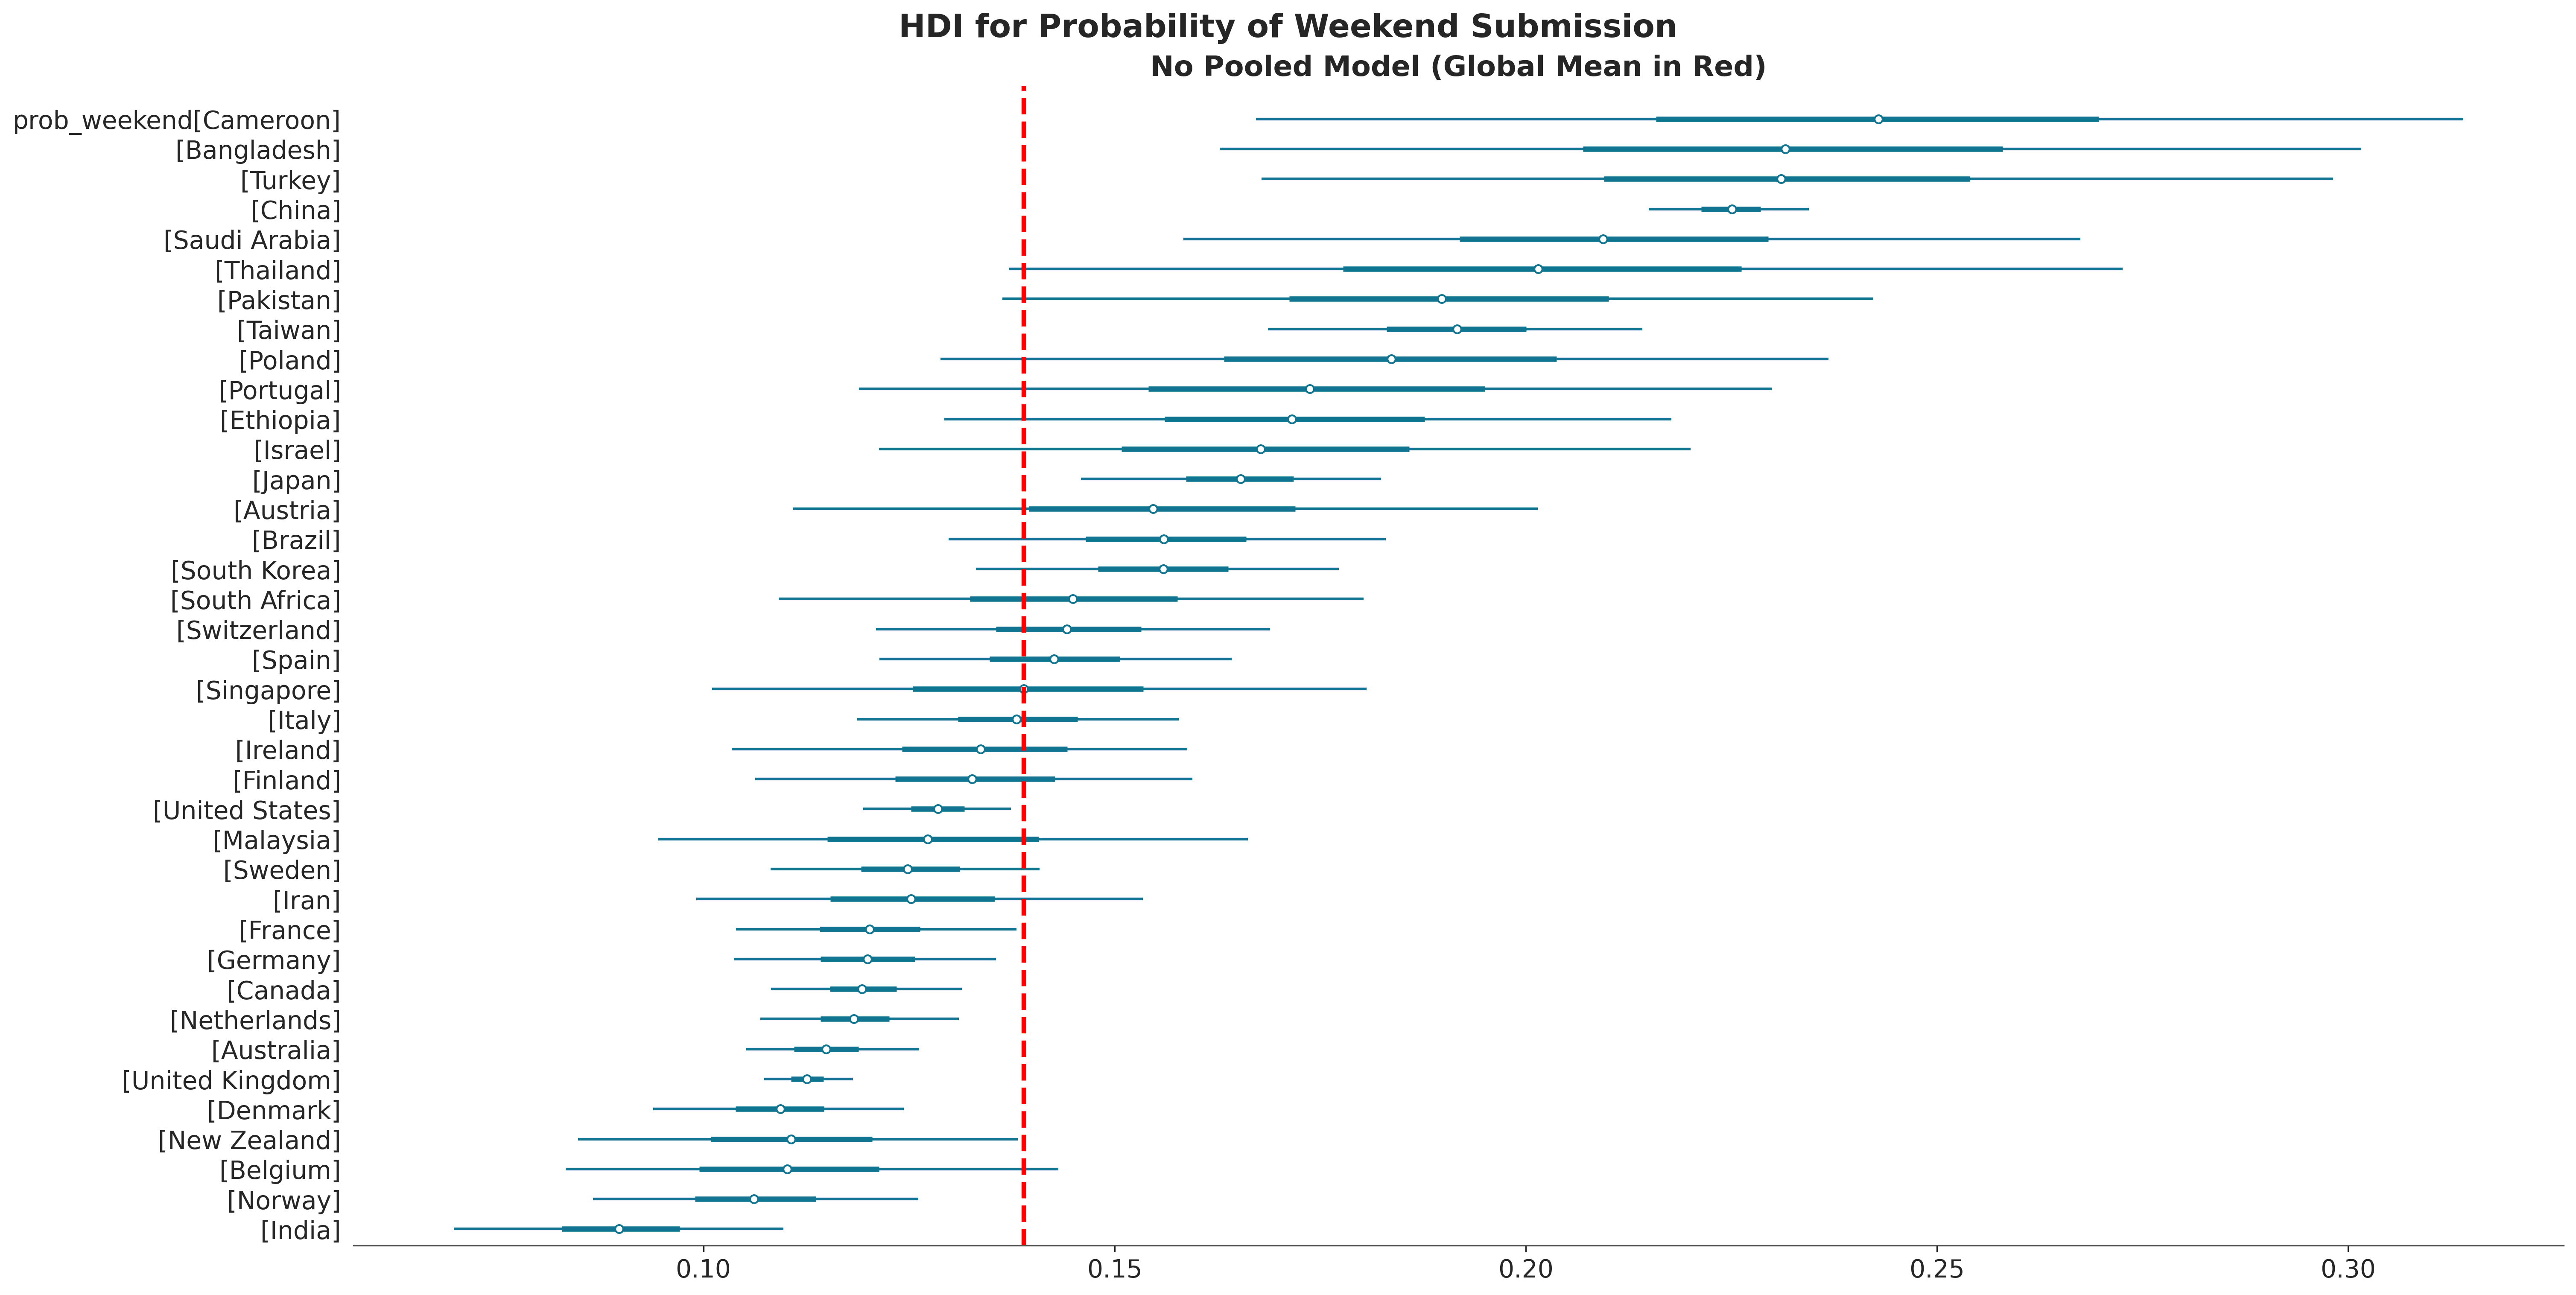

In [90]:
_, ax = plt.subplots(figsize=(20, 10))
az.plot_forest(prob_weekend_no_pool[:, :, list(new_countries_dict.values())],
              kind="forestplot",
              combined=True,
              ax=ax,
              )
ax.axvline(global_avg, color="red", ls="--", lw=2.5)
plt.suptitle("HDI for Probability of Weekend Submission")
ax.set_title("No Pooled Model (Global Mean in Red)")
plt.show()

## Partial Pooling Case <br>
Model is similar <br>
<center> $\mu = a + b[id]$ </center>
<center> $p = invlogit(\mu)$ </center>
<center> $a \sim Normal(-1, 1)$ </center>
<center> $b \sim Normal(\bar{b}, \sigma)$ </center>
<center> $\bar{b} \sim Normal(0, 0.5)$ </center>
<center> $\sigma \sim Exponential(1.)$ </center>

In [104]:
with pm.Model(coords=COORDS) as partial_pooled_model:

    # Data Containers
    country_id = pm.Data("country_id", country_idx, dims="obs")
    W = pm.Data("W", df["W"].values, dims="obs")

    # Priors
    a = pm.Normal("a", mu=-2., sigma=1.)
    
    # Hyper parameters
    σ = pm.Exponential("σ", 1)
    b = pm.Normal("b", mu=0, sigma=σ, dims="country") # This is the partial pooling here! (Note did not include a hyperparameter
    # for mu here!)

    p = pm.math.invlogit(a + b[country_id]) # Probability of weekend submission

    # Bernoulli Likelihood
    W_obs = pm.Bernoulli("W_obs", p=p, observed=W, dims="obs")

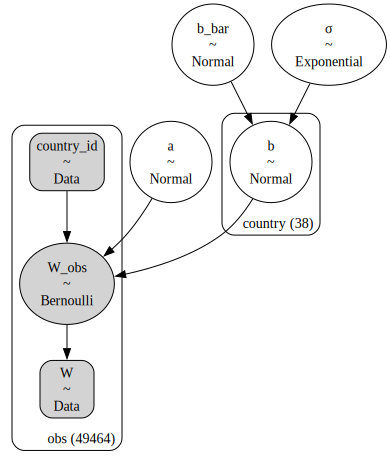

In [93]:
pm.model_to_graphviz(partial_pooled_model)

In [102]:
# Sampling!
with partial_pooled_model:
    idata_partial_pooled = pm.sample(random_seed=random_seed)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, σ, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 42 seconds.


In [103]:
az.summary(idata_partial_pooled, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,-1.78,0.05,-1.87,-1.69,0.0,0.0,1011.83,1531.92,1.0
b[Australia],-0.26,0.07,-0.39,-0.12,0.0,0.0,1738.78,2213.44,1.0
b[Austria],0.06,0.17,-0.23,0.41,0.0,0.0,5578.36,3018.56,1.0
b[Bangladesh],0.42,0.20,0.04,0.77,0.0,0.0,6203.00,3301.59,1.0
b[Belgium],-0.26,0.15,-0.54,0.03,0.0,0.0,5064.54,2664.30,1.0
b[Brazil],0.08,0.11,-0.14,0.28,0.0,0.0,3544.39,2852.36,1.0
b[Cameroon],0.46,0.19,0.10,0.82,0.0,0.0,4687.58,3033.19,1.0
b[Canada],-0.22,0.07,-0.35,-0.08,0.0,0.0,2069.68,2729.10,1.0
b[China],0.54,0.06,0.43,0.64,0.0,0.0,1307.67,2264.85,1.0
b[Denmark],-0.30,0.09,-0.48,-0.13,0.0,0.0,2651.24,2327.97,1.0


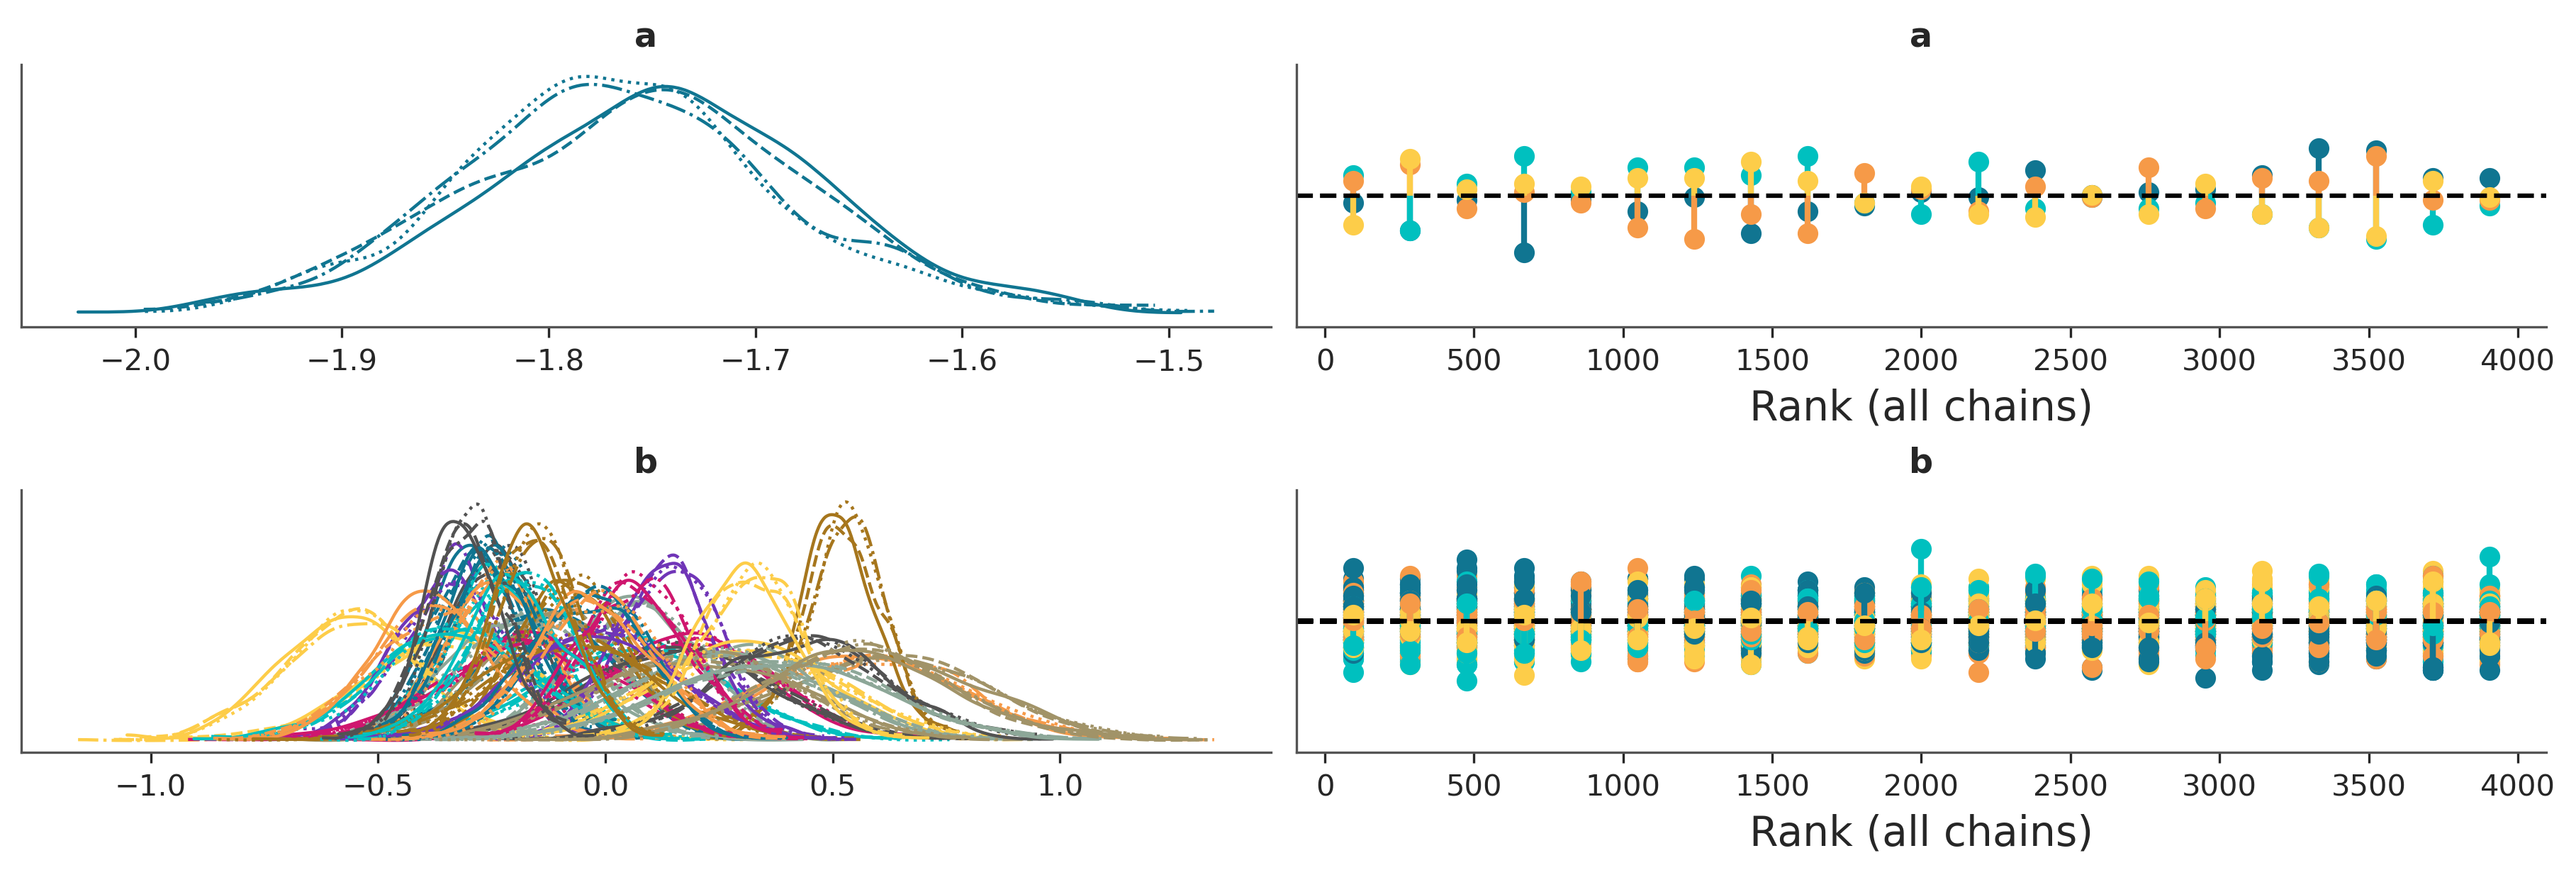

In [105]:
az.plot_trace(idata_no_pooled, kind="rank_vlines")
plt.show()

In [107]:
# Calculate the probability of weekend submission
prob_weekend_partial_pooled = expit(idata_partial_pooled.posterior["a"] + 
                                    idata_partial_pooled.posterior["b"]
                                   ) # This broadcasts to all shapes
prob_weekend_partial_pooled = prob_weekend_partial_pooled.rename("prob_weekend")

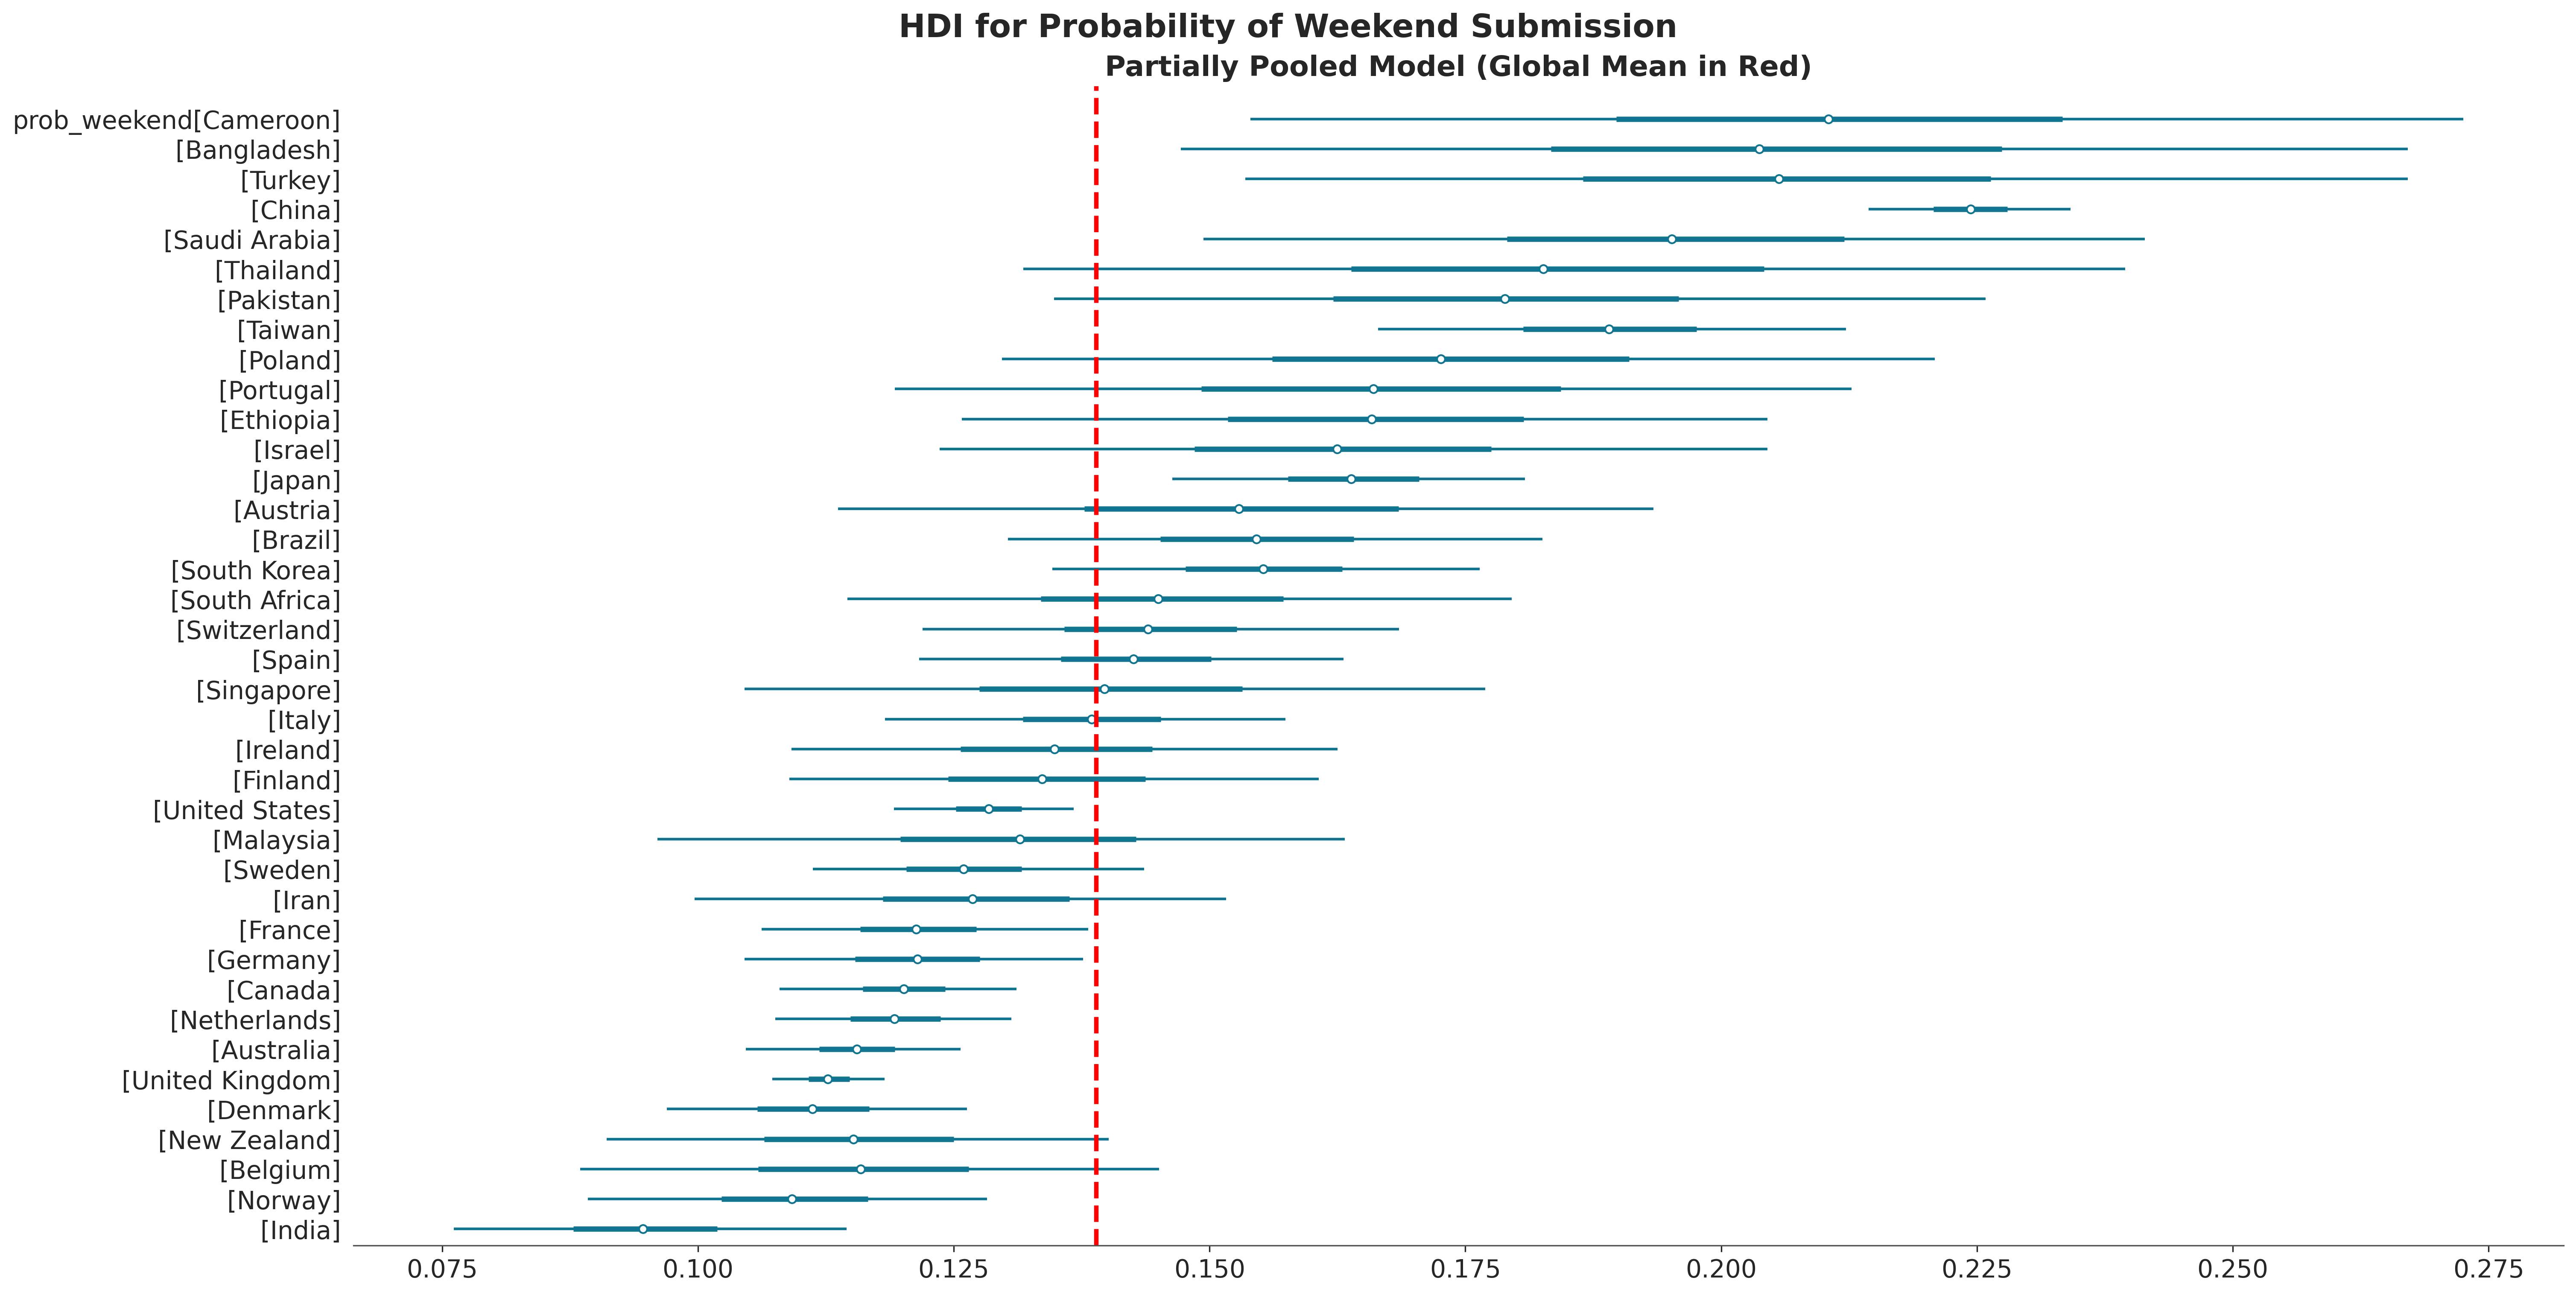

In [117]:
# Make plot
_, ax = plt.subplots(figsize=(20., 10.))
az.plot_forest(
    prob_weekend_partial_pooled[:, :, list(new_countries_dict.values())],
    combined=True,
    #backend_kwargs={"figsize": (20., 10.)},
    ax=ax
)
ax.axvline(global_avg, color="red", ls="--", lw=2.5)
plt.suptitle("HDI for Probability of Weekend Submission")
ax.set_title("Partially Pooled Model (Global Mean in Red)")
plt.show()

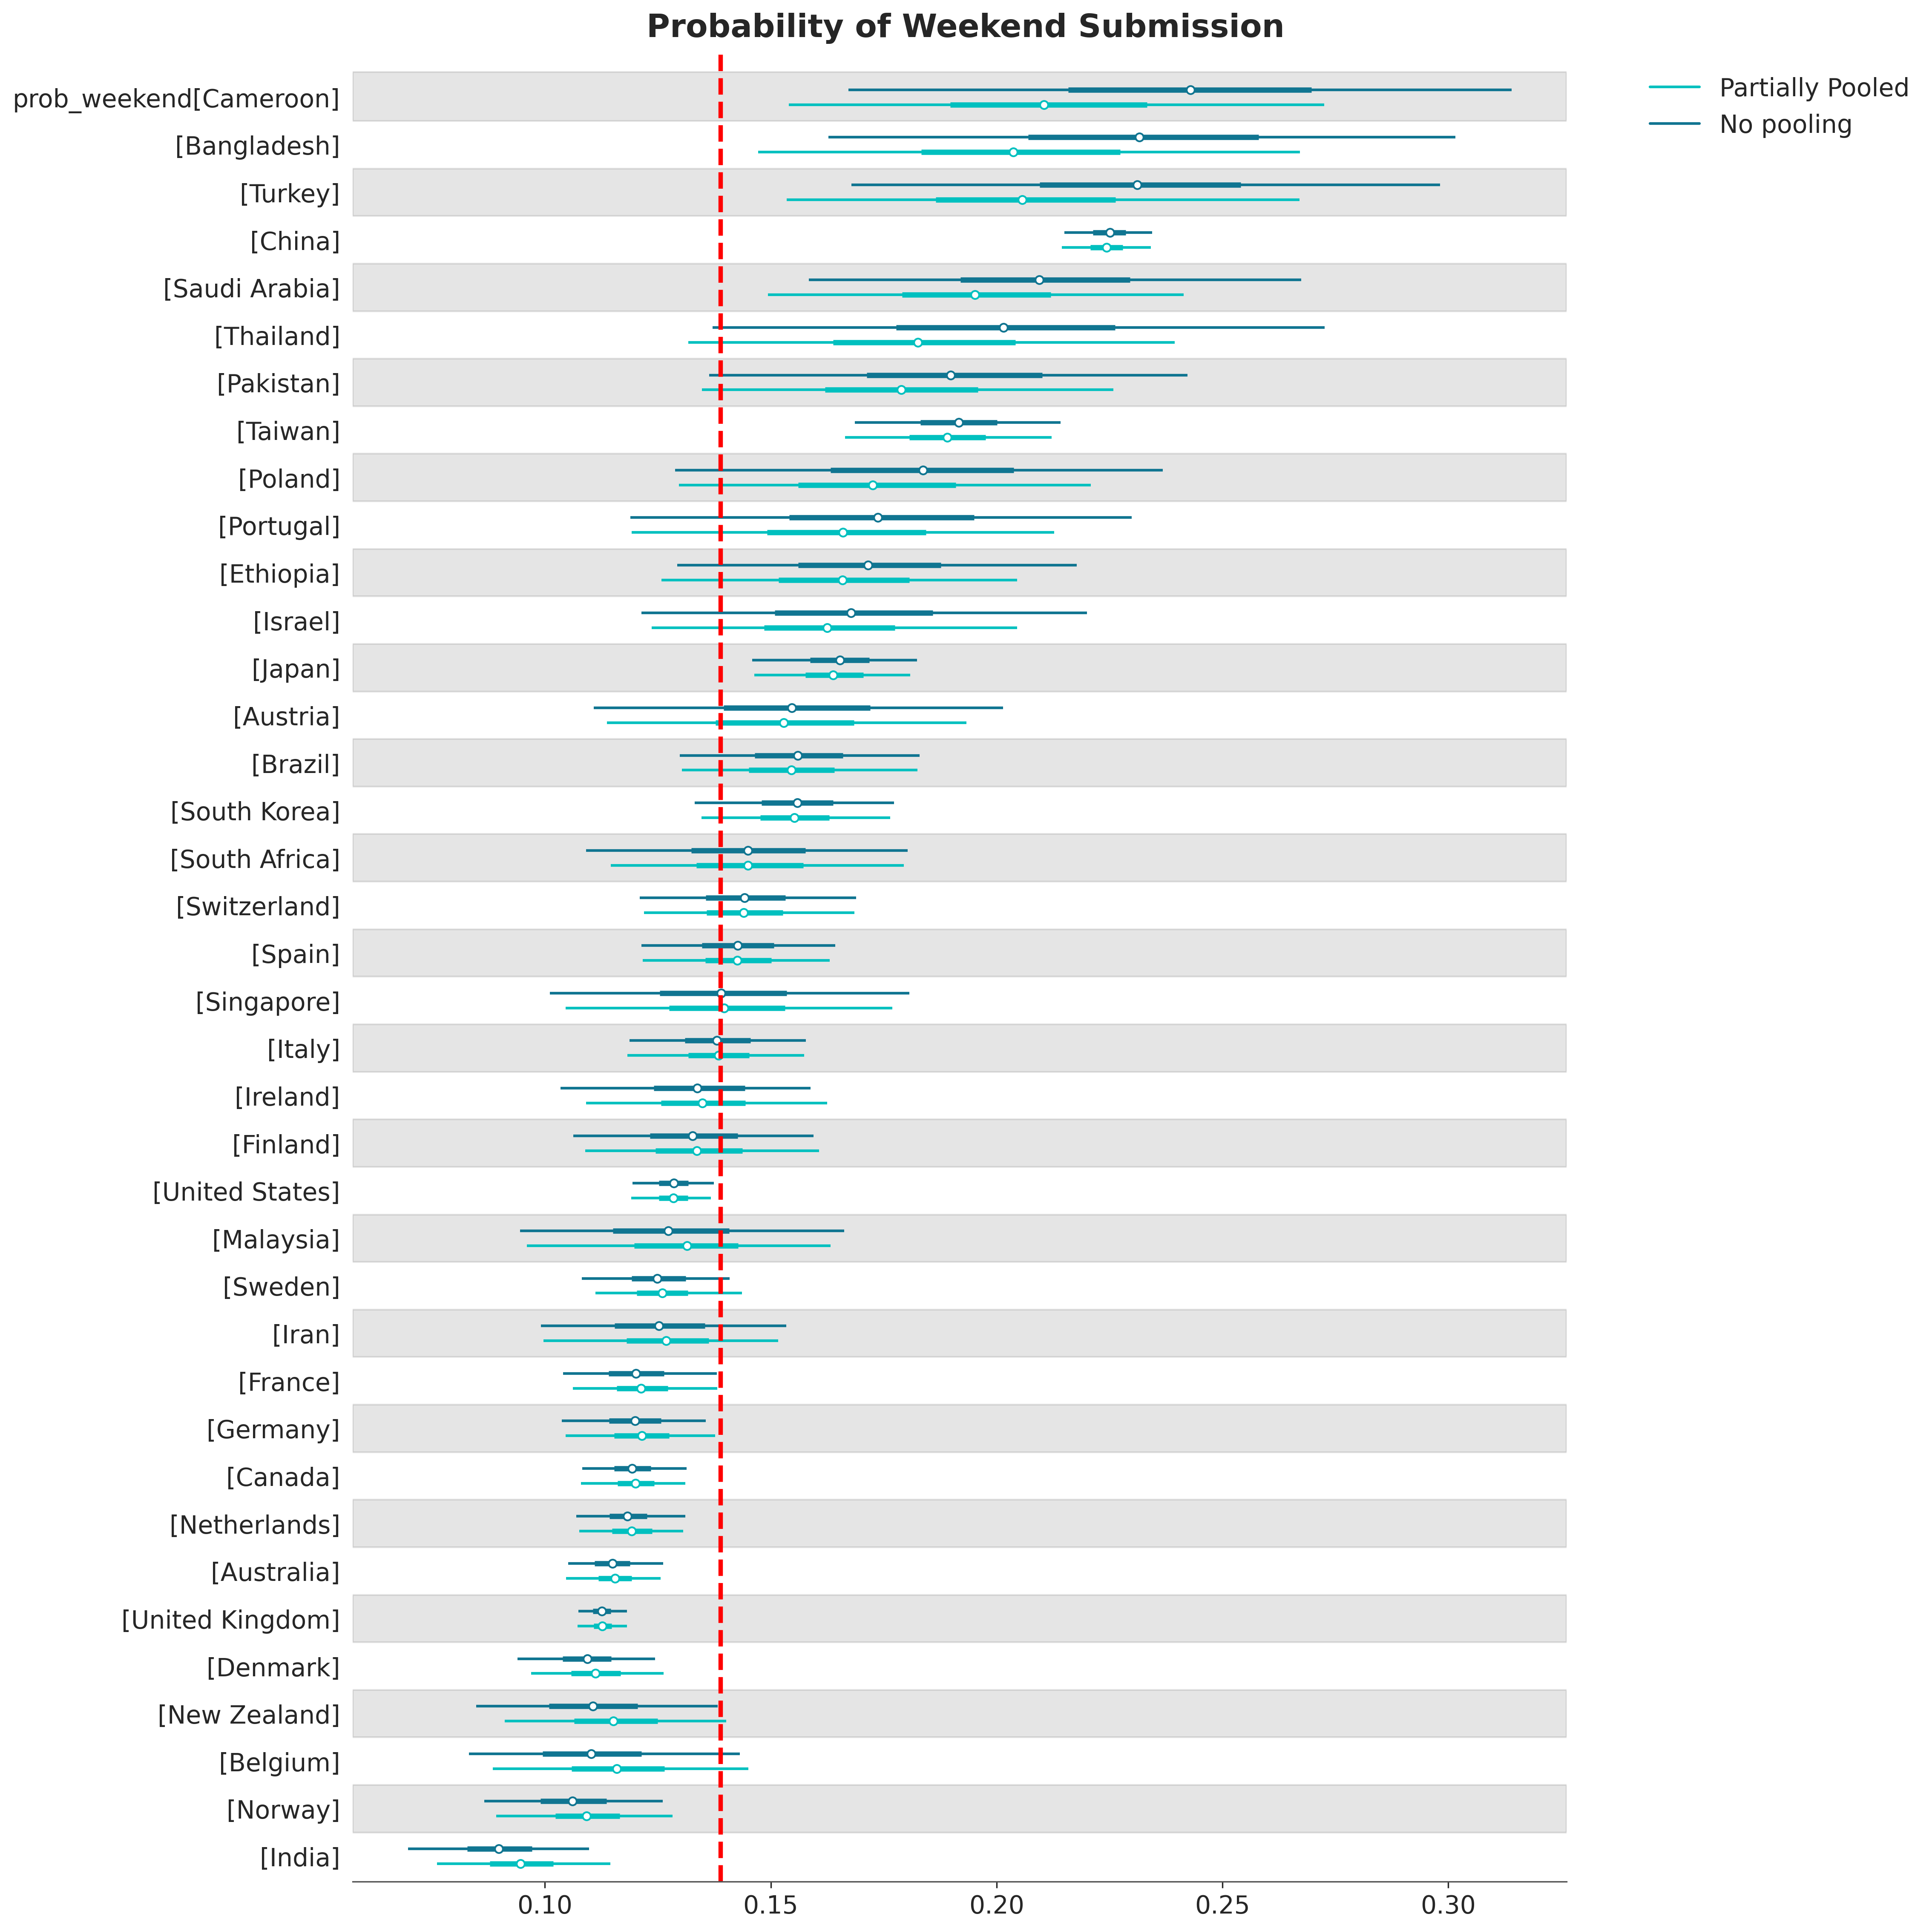

In [138]:
_, ax = plt.subplots(figsize=(15., 15.))
az.plot_forest(
    data = [
        prob_weekend_no_pool[:, :, list(new_countries_dict.values())],
        prob_weekend_partial_pooled[:, :, list(new_countries_dict.values())]
    ],
    model_names=["No pooling", "Partially Pooled"],
    kind="forestplot",
    combined=True,
    ax=ax,
    backend_kwargs={"bbox_to_anchor": (1.1, 0.5), "loc": "upper left"}
)
ax.axvline(global_avg, color="red", ls="--", lw=2.5)
plt.suptitle("Probability of Weekend Submission")
ax.set_title("")

leg = ax.get_legend()

# Move it outside (e.g., to the right)
leg.set_bbox_to_anchor((1.05, 1))
leg.set_loc('upper left')

plt.show()